# Eda 

Đang bắt đầu quá trình Phân tích Dữ liệu Khám phá (EDA)...
Tải dữ liệu train.csv...

--- 1. Thông tin cơ bản (df_train.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType 

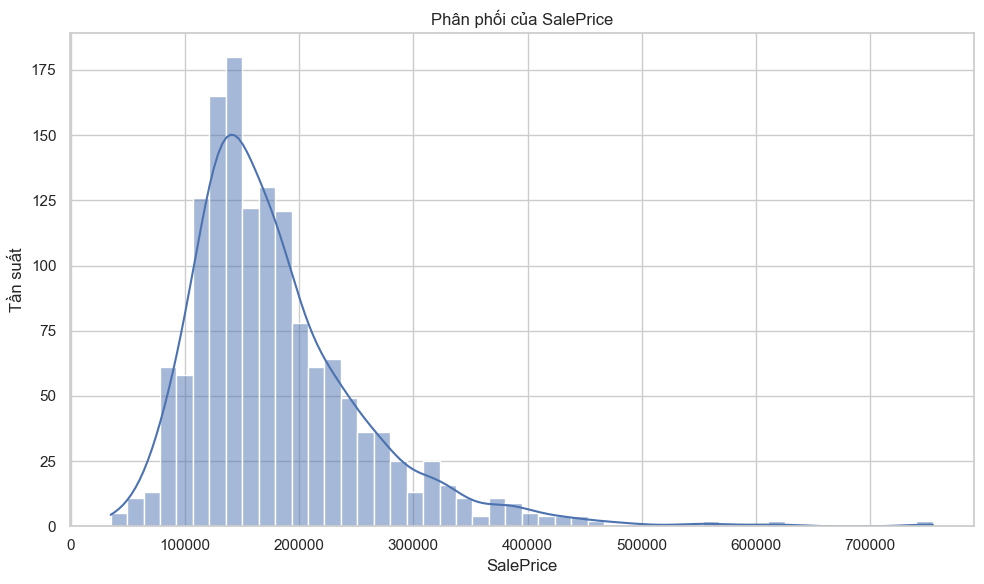

Đã lưu 'saleprice_distribution.png'
Đang tạo biểu đồ phân phối log(SalePrice + 1)...


<Figure size 640x480 with 0 Axes>

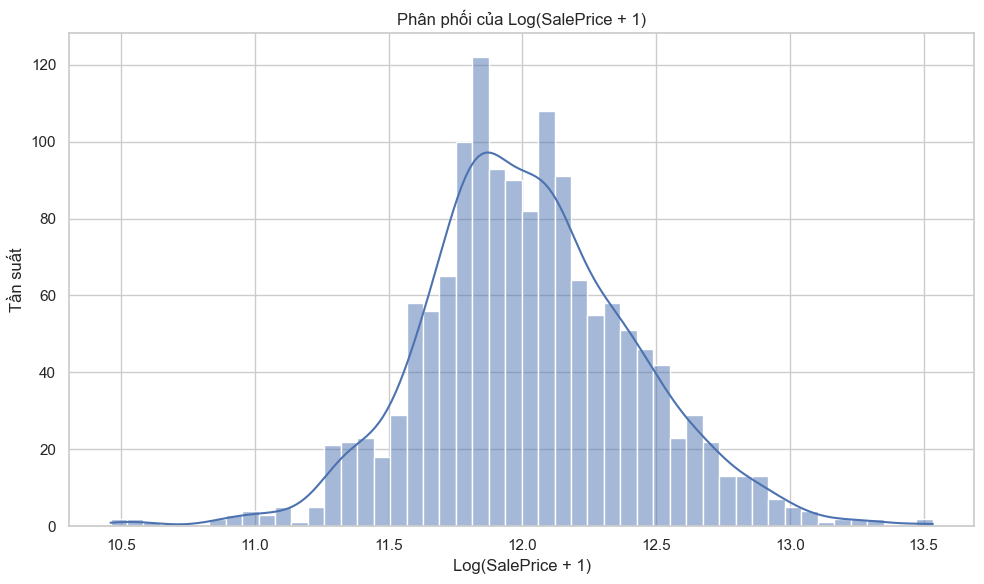

Đã lưu 'saleprice_log_distribution.png'

Đang phân tích dữ liệu bị thiếu (missing data)...
Các cột có dữ liệu bị thiếu (%):
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


<Figure size 640x480 with 0 Axes>

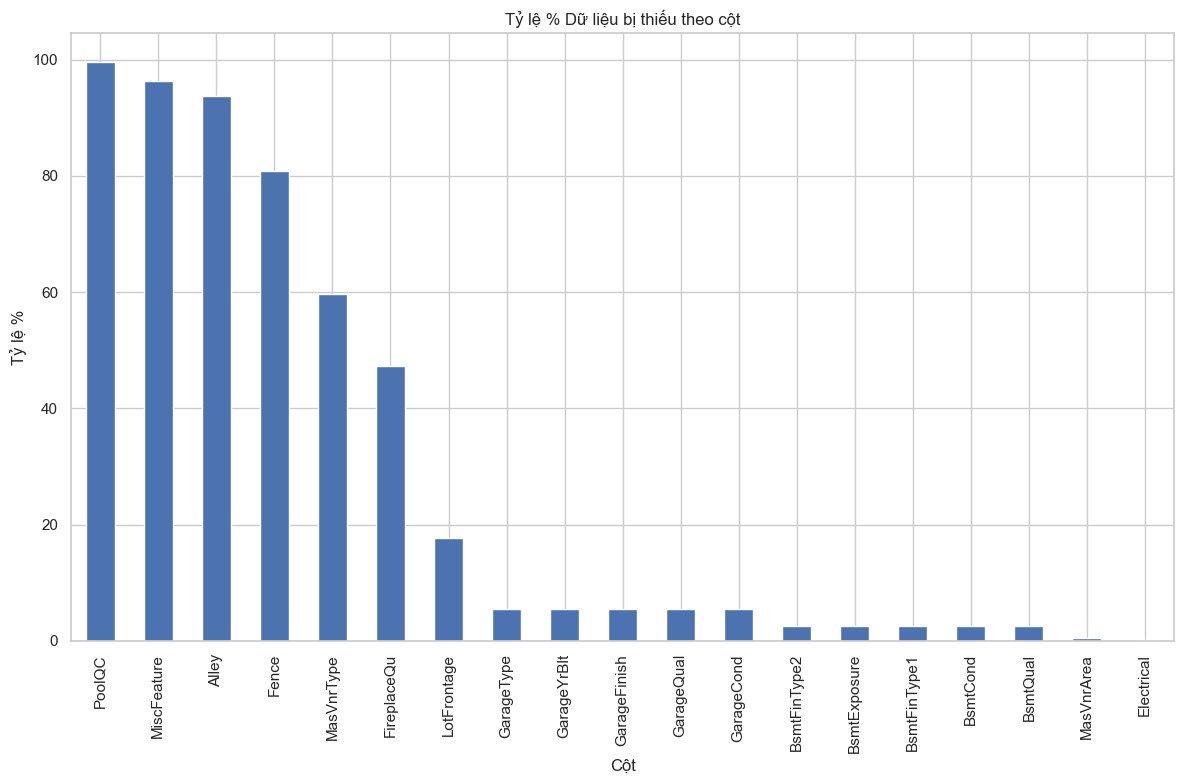

Đã lưu 'missing_values_plot.png'

Đang tạo heatmap tương quan...


<Figure size 640x480 with 0 Axes>

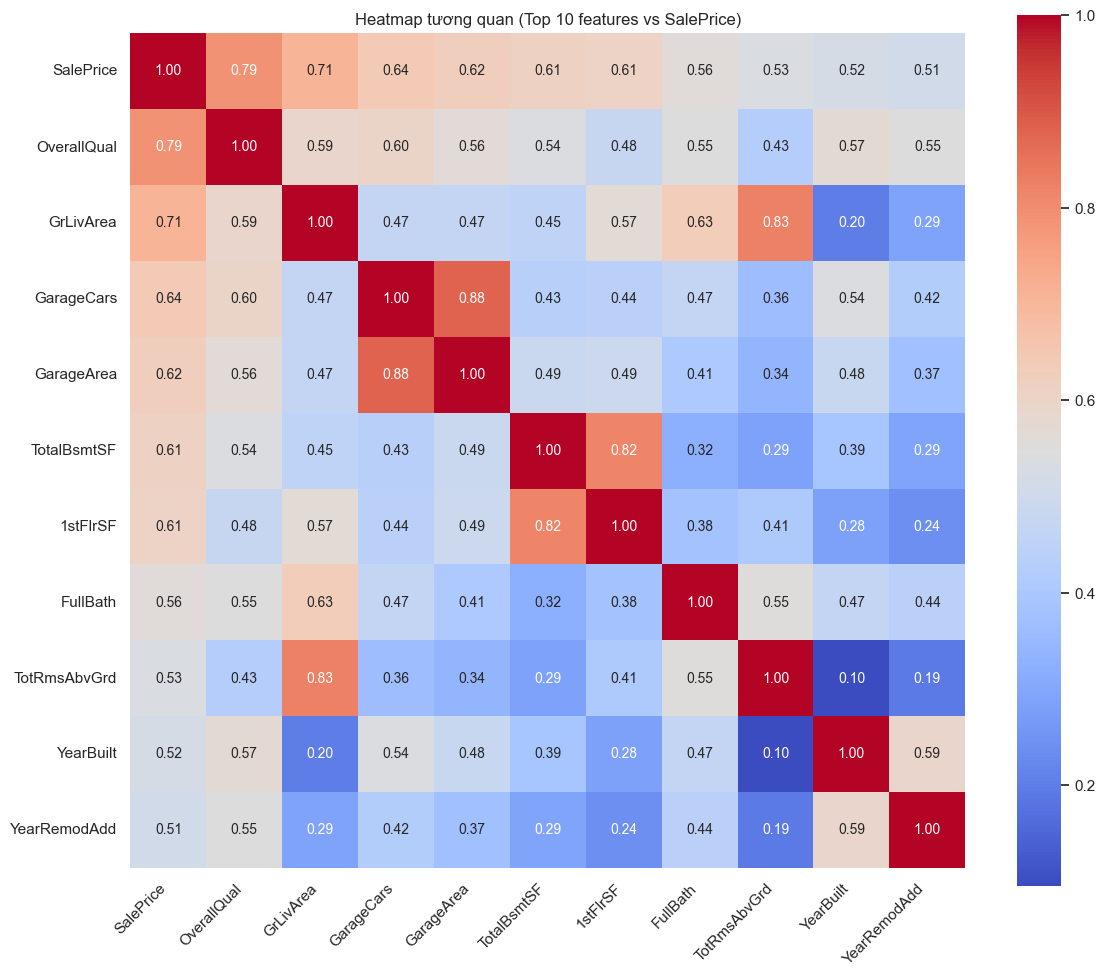

Đã lưu 'correlation_heatmap.png'

Đang tạo các biểu đồ quan hệ Feature - Target...


<Figure size 640x480 with 0 Axes>

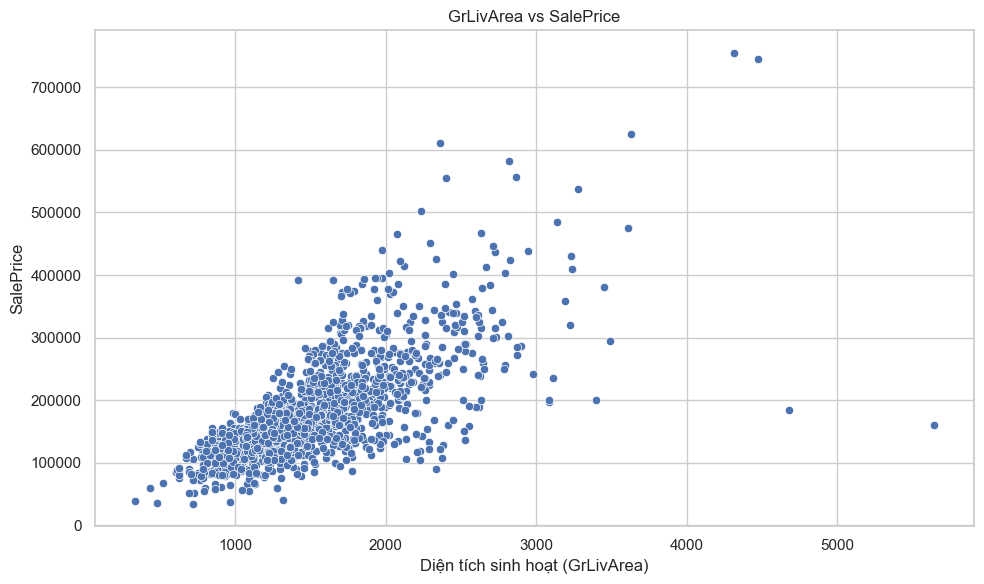

Đã lưu 'scatter_grlivarea_saleprice.png'


<Figure size 640x480 with 0 Axes>

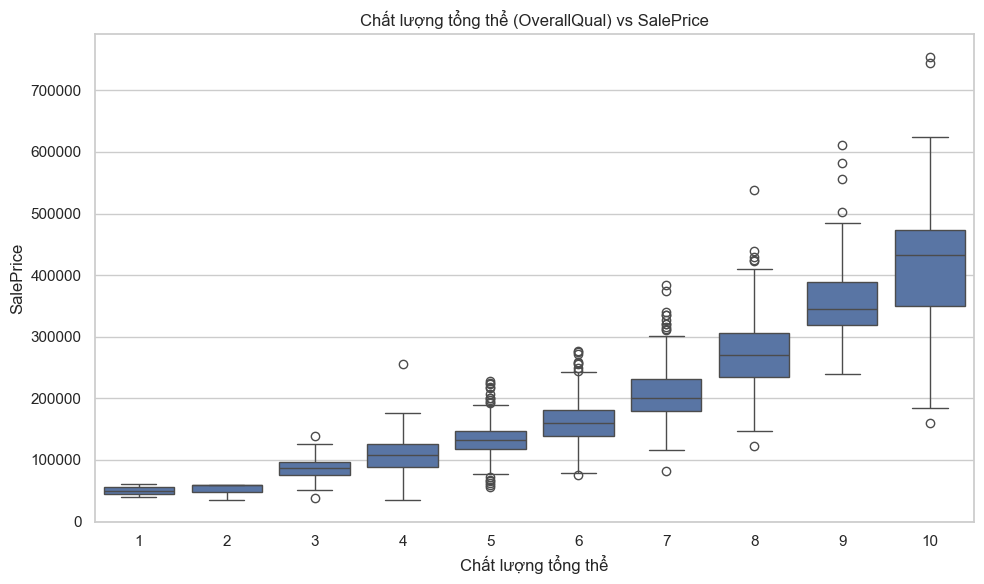

Đã lưu 'boxplot_overallqual_saleprice.png'


<Figure size 640x480 with 0 Axes>

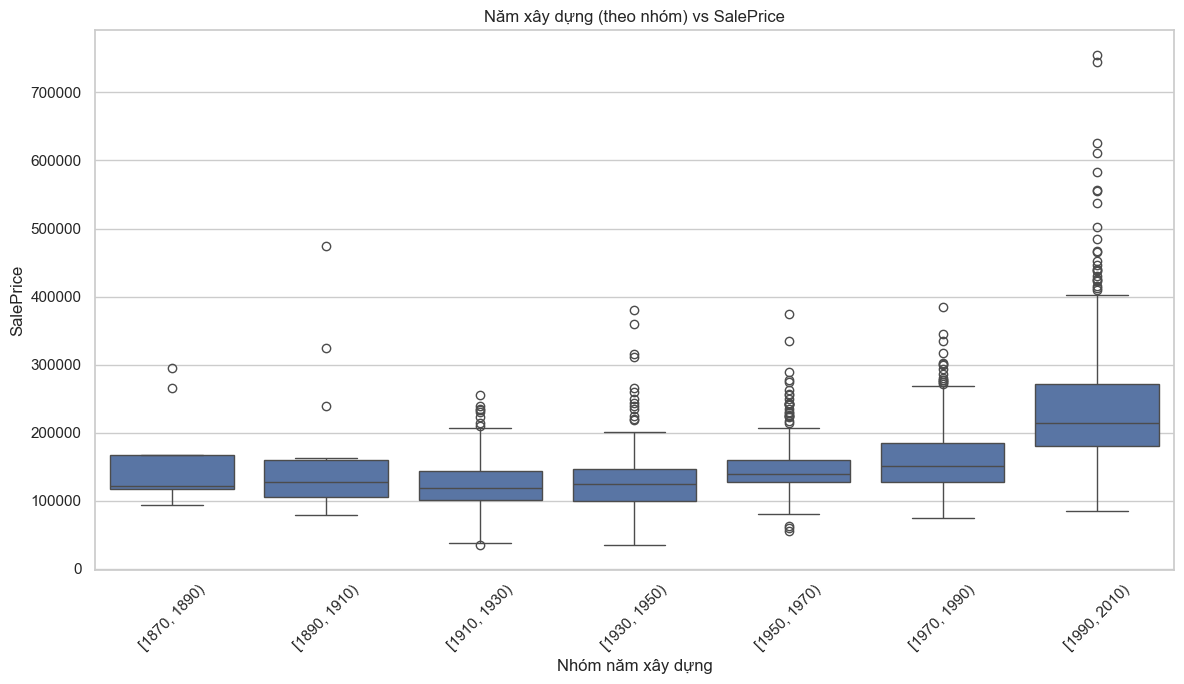

Đã lưu 'boxplot_yearbuilt_saleprice.png'

--- Hoàn thành EDA! ---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Enable inline plotting in the notebook
get_ipython().run_line_magic('matplotlib', 'inline')

# Set style cho seaborn
sns.set(style="whitegrid")

print("Đang bắt đầu quá trình Phân tích Dữ liệu Khám phá (EDA)...")
print("Tải dữ liệu train.csv...")

try:
    # Load data
    df_train = pd.read_csv('../data/txt/train.csv')
    # Tạo thư mục lưu ảnh nếu chưa có
    os.makedirs('../data/png', exist_ok=True)

    print("\n--- 1. Thông tin cơ bản (df_train.info()) ---")
    # Ghi .info() vào một string để in ra stdout
    import io
    buffer = io.StringIO()
    df_train.info(buf=buffer)
    print(buffer.getvalue())

    print("\n--- 2. 5 dòng đầu tiên (df_train.head()) ---")
    print(df_train.head())

    print("\n--- 3. Thống kê mô tả (df_train.describe()) ---")
    print(df_train.describe())

    # --- 4. Phân tích biến mục tiêu (SalePrice) ---
    print("\nĐang tạo biểu đồ phân phối SalePrice...")
    plt.figure(figsize=(10, 6))
    sns.histplot(df_train['SalePrice'], kde=True, bins=50)
    plt.title('Phân phối của SalePrice')
    plt.xlabel('SalePrice')
    plt.ylabel('Tần suất')
    plt.tight_layout()
    plt.savefig('../data/png/saleprice_distribution.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf() # Clear figure để chuẩn bị cho plot tiếp theo
    print("Đã lưu 'saleprice_distribution.png'")

    # Phân phối SalePrice sau khi log transform
    print("Đang tạo biểu đồ phân phối log(SalePrice + 1)...")
    plt.figure(figsize=(10, 6))
    # Sử dụng np.log1p (tương đương log(1 + x)) để tránh lỗi log(0)
    sns.histplot(np.log1p(df_train['SalePrice']), kde=True, bins=50)
    plt.title('Phân phối của Log(SalePrice + 1)')
    plt.xlabel('Log(SalePrice + 1)')
    plt.ylabel('Tần suất')
    plt.tight_layout()
    plt.savefig('../data/png/saleprice_log_distribution.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf()
    print("Đã lưu 'saleprice_log_distribution.png'")

    # --- 5. Phân tích Missing Data ---
    print("\nĐang phân tích dữ liệu bị thiếu (missing data)...")
    missing_percent = (df_train.isnull().sum() / len(df_train)) * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
    if not missing_percent.empty:
        print("Các cột có dữ liệu bị thiếu (%):")
        print(missing_percent)
        
        plt.figure(figsize=(12, 8))
        missing_percent.plot(kind='bar')
        plt.title('Tỷ lệ % Dữ liệu bị thiếu theo cột')
        plt.xlabel('Cột')
        plt.ylabel('Tỷ lệ %')
        plt.tight_layout()
        plt.savefig('../data/png/missing_values_plot.png')
        plt.show()       # <-- Hiển thị ngay trong notebook
        plt.clf()
        print("Đã lưu 'missing_values_plot.png'")
    else:
        print("Không có dữ liệu bị thiếu trong train.csv.")

    # --- 6. Phân tích tương quan (Correlation) ---
    print("\nĐang tạo heatmap tương quan...")
    # Lấy các cột số
    numerical_cols = df_train.select_dtypes(include=np.number).columns
    corr_matrix = df_train[numerical_cols].corr()
    
    # Lấy top 11 (SalePrice + 10) features tương quan nhất với SalePrice
    k = 11 
    top_corr_cols = corr_matrix.nlargest(k, 'SalePrice')['SalePrice'].index
    top_corr_matrix = df_train[top_corr_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, annot_kws={'size': 10})
    plt.title(f'Heatmap tương quan (Top {k-1} features vs SalePrice)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../data/png/correlation_heatmap.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf()
    print("Đã lưu 'correlation_heatmap.png'")

    # --- 7. Phân tích quan hệ Feature - Target ---
    print("\nĐang tạo các biểu đồ quan hệ Feature - Target...")

    # Scatter plot: GrLivArea vs SalePrice
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'])
    plt.title('GrLivArea vs SalePrice')
    plt.xlabel('Diện tích sinh hoạt (GrLivArea)')
    plt.ylabel('SalePrice')
    plt.tight_layout()
    plt.savefig('../data/png/scatter_grlivarea_saleprice.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf()
    print("Đã lưu 'scatter_grlivarea_saleprice.png'")

    # Box plot: OverallQual vs SalePrice
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_train['OverallQual'], y=df_train['SalePrice'])
    plt.title('Chất lượng tổng thể (OverallQual) vs SalePrice')
    plt.xlabel('Chất lượng tổng thể')
    plt.ylabel('SalePrice')
    plt.tight_layout()
    plt.savefig('../data/png/boxplot_overallqual_saleprice.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf()
    print("Đã lưu 'boxplot_overallqual_saleprice.png'")

    # Box plot: YearBuilt vs SalePrice
    # Nhóm các năm lại để biểu đồ dễ đọc hơn (chia theo mỗi 20 năm)
    df_train['YearBuilt_Group'] = pd.cut(df_train['YearBuilt'], bins=range(1870, 2030, 20), right=False)
    
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='YearBuilt_Group', y='SalePrice', data=df_train)
    plt.title('Năm xây dựng (theo nhóm) vs SalePrice')
    plt.xlabel('Nhóm năm xây dựng')
    plt.ylabel('SalePrice')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../data/png/boxplot_yearbuilt_saleprice.png')
    plt.show()         # <-- Hiển thị ngay trong notebook
    plt.clf()
    print("Đã lưu 'boxplot_yearbuilt_saleprice.png'")

    print("\n--- Hoàn thành EDA! ---")

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'train.csv'. Vui lòng kiểm tra lại tên file.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")